In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data_for_test_10000 NEW.csv')

In [3]:
df.head()

,ID,Fullname,Birthday,Sex,Hometown,Jobtype,Salary,Marital Status
0,123456789012,Nguyen Van A,12/09/1985,Male,Tra Vinh,Software Engineer,15,Married
1,123456789013,Nguyen Van Anh,15/08/1990,Male,Quang Nam,Software Engineer,500,Married
2,123456789014,Nguyen Van Anh,20/07/1985,Female,Hung Yen,Architect,700,Married
3,123456789015,Tran Thi Minh Thu,12/05/1987,Female,Thanh pho Can Tho,Architect,200,Married
4,123456789016,Nguyen Van A,20/03/1990,Male,Ba Ria - Vung Tau,Architect,500,Single


In [4]:
age_lst = []

for i in df['Birthday']:
    month =  int(i.split('/')[1])
    year = int(i.split('/')[2])

    if 1 - month < 0:
        age_lst.append(2024 - year)
    else:
        age_lst.append(2024 - year + 1)

new_df = df.copy()
new_df['Age'] = age_lst
move_col = new_df.pop('Age')
new_df.insert(3, 'Age', move_col)

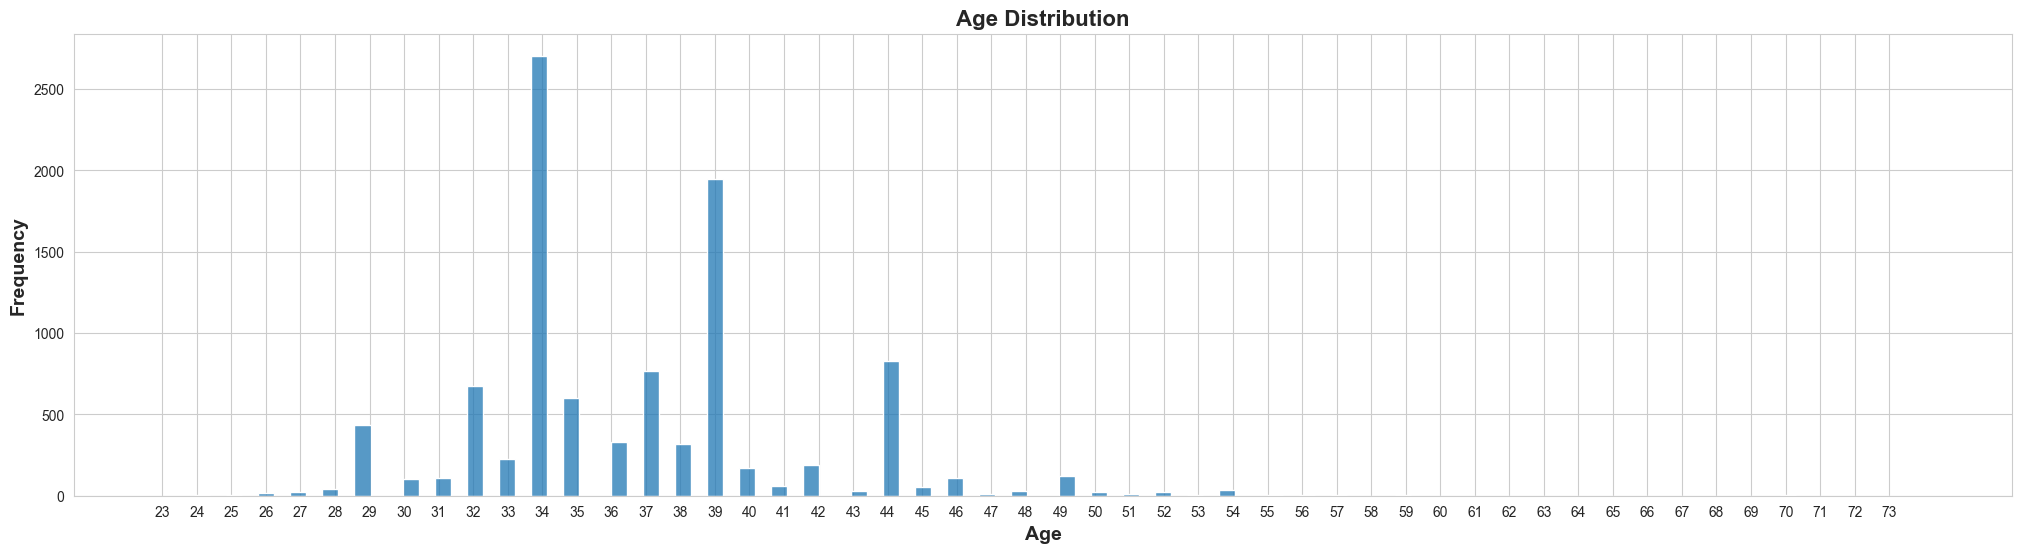

In [6]:
sns.set_style('whitegrid')

plt.figure(figsize = (25, 6))
sns.histplot(new_df['Age'])

plt.xticks(np.arange(new_df['Age'].min(), new_df['Age'].max()))

plt.title('Age Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.show()


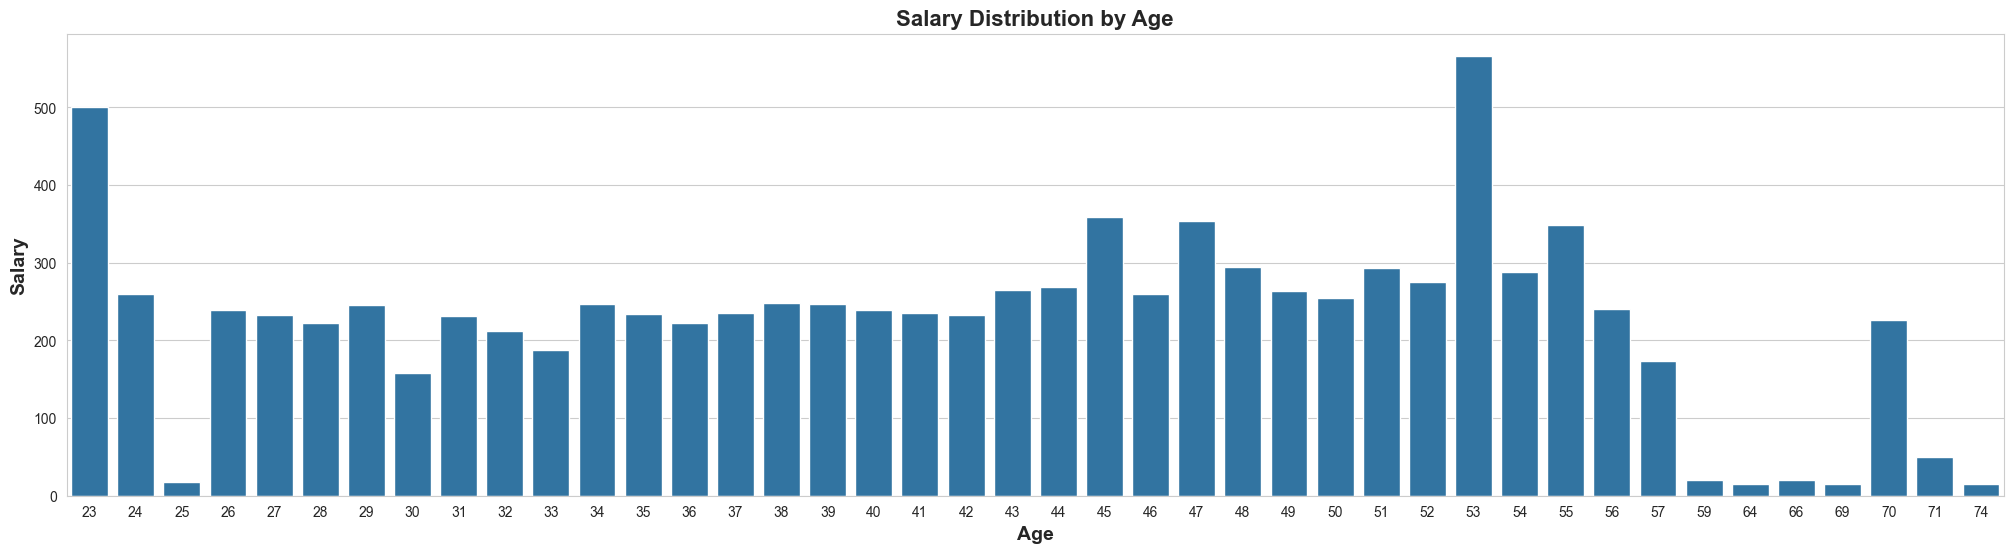

In [7]:
sns.set_style('whitegrid')

age_salary = new_df.groupby('Age')['Salary'].mean().reset_index()

plt.figure(figsize = (25, 6))

sns.barplot(x = 'Age', y = 'Salary', data = age_salary)

plt.title('Salary Distribution by Age', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=14, fontweight='bold')
plt.ylabel('Salary', fontsize=14, fontweight='bold')

plt.show()

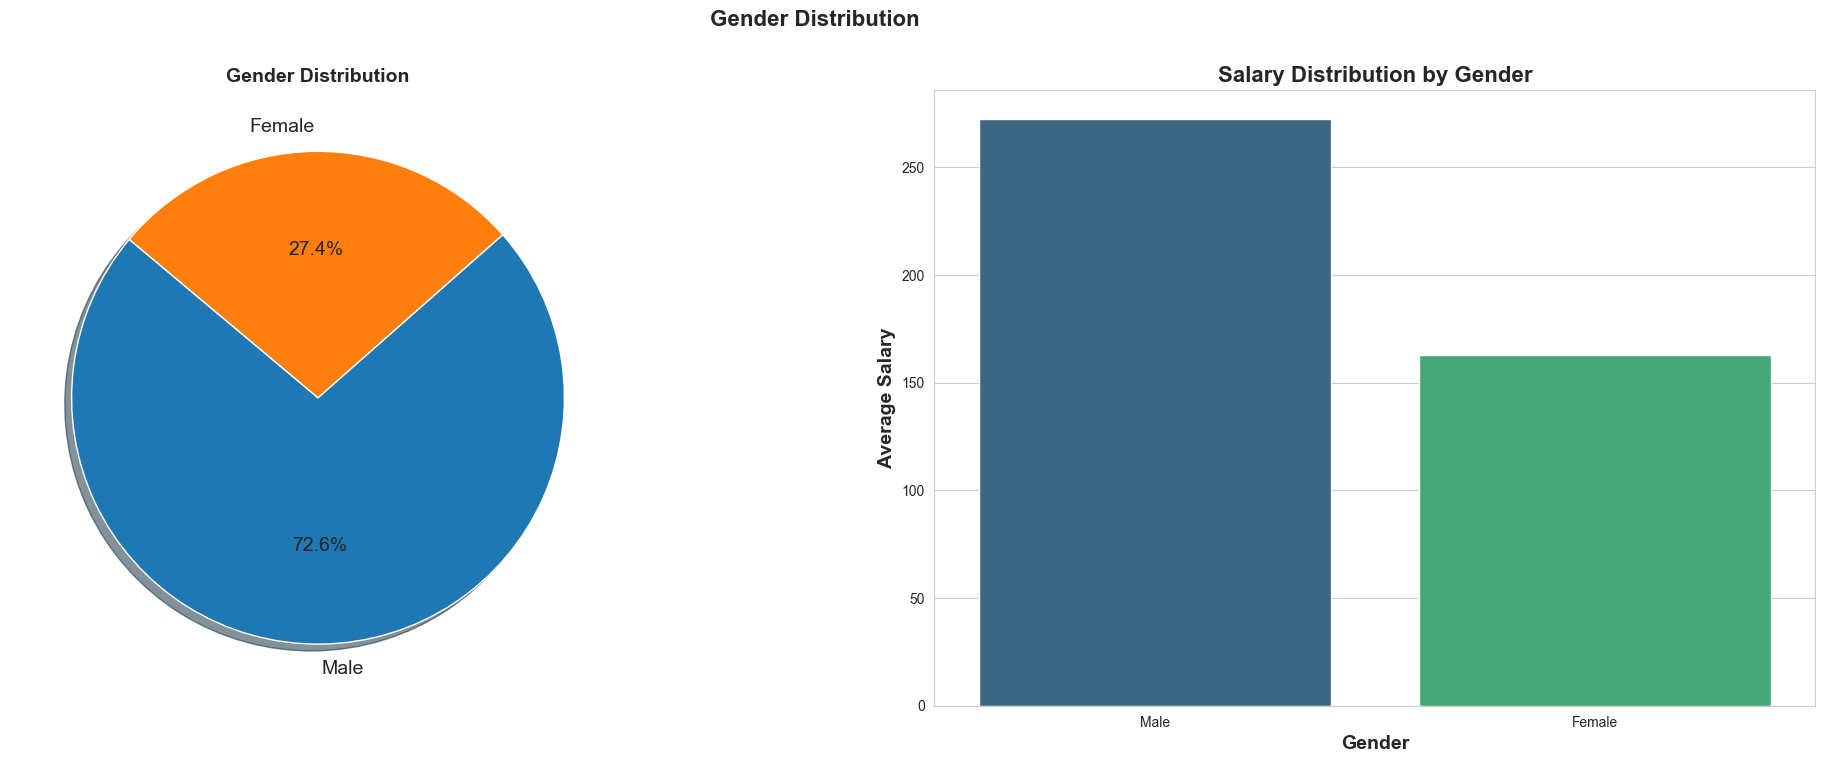

In [8]:
sns.set_style('whitegrid')

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(25, 8))

gender_counts = df['Sex'].value_counts()
ax1 = axes[0]
ax1.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', shadow=True, startangle=140, textprops={'fontsize': 14})
ax1.set_title('Gender Distribution', fontsize=14, fontweight='bold')

ax2 = axes[1]
sns.barplot(x='Sex', y='Salary', data=df, palette='viridis', ci=None, ax=ax2)
ax2.set_title('Salary Distribution by Gender', fontsize=16, fontweight='bold')
ax2.set_xlabel('Gender', fontsize=14, fontweight='bold')
ax2.set_ylabel('Average Salary', fontsize=14, fontweight='bold')

fig.suptitle('Gender Distribution', fontsize=16, fontweight='bold')

# Show plot
plt.show()

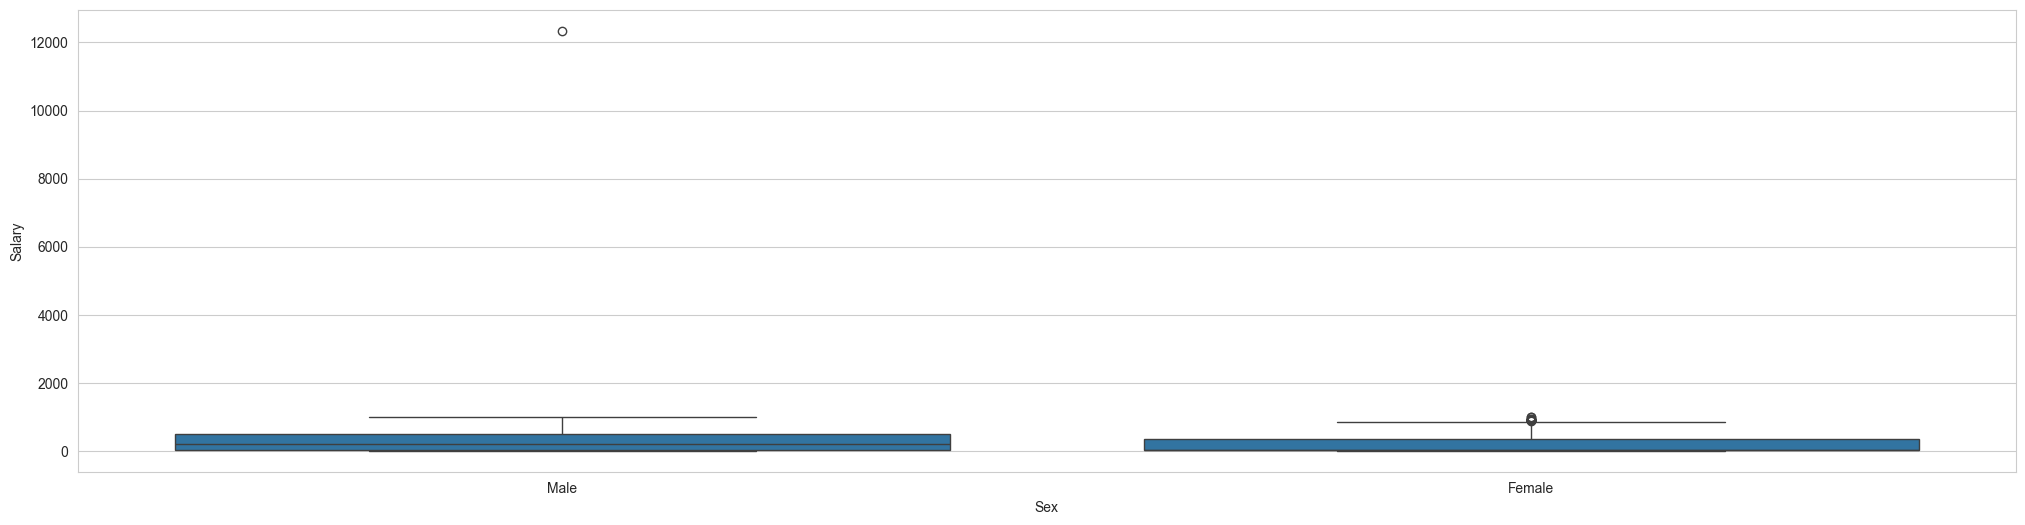

In [9]:
sns.set_style('whitegrid')

plt.figure(figsize = (25, 6))
sns.boxplot(data = df, x = 'Sex', y = 'Salary')

plt.show()

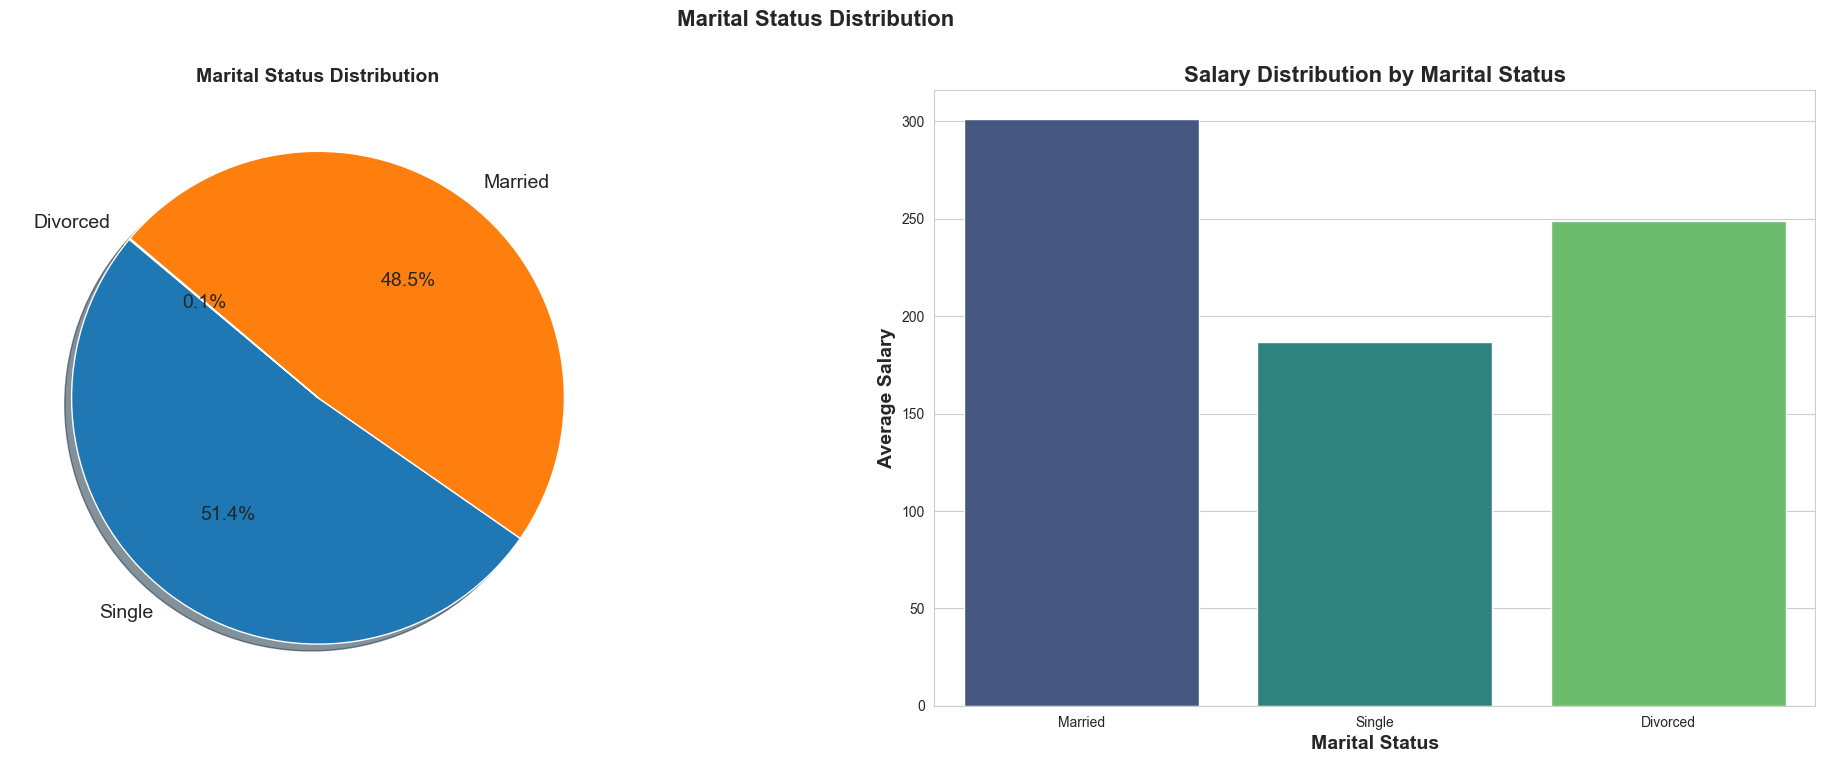

In [10]:
sns.set_style('whitegrid')

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(25, 8))

gender_counts = df['Marital Status'].value_counts()
ax1 = axes[0]
ax1.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', shadow=True, startangle=140, textprops={'fontsize': 14})
ax1.set_title('Marital Status Distribution', fontsize=14, fontweight='bold')

ax2 = axes[1]
sns.barplot(x='Marital Status', y='Salary', data=df, palette='viridis', ci=None, ax=ax2)
ax2.set_title('Salary Distribution by Marital Status', fontsize=16, fontweight='bold')
ax2.set_xlabel('Marital Status', fontsize=14, fontweight='bold')
ax2.set_ylabel('Average Salary', fontsize=14, fontweight='bold')

fig.suptitle('Marital Status Distribution', fontsize=16, fontweight='bold')

# Show plot
plt.show()

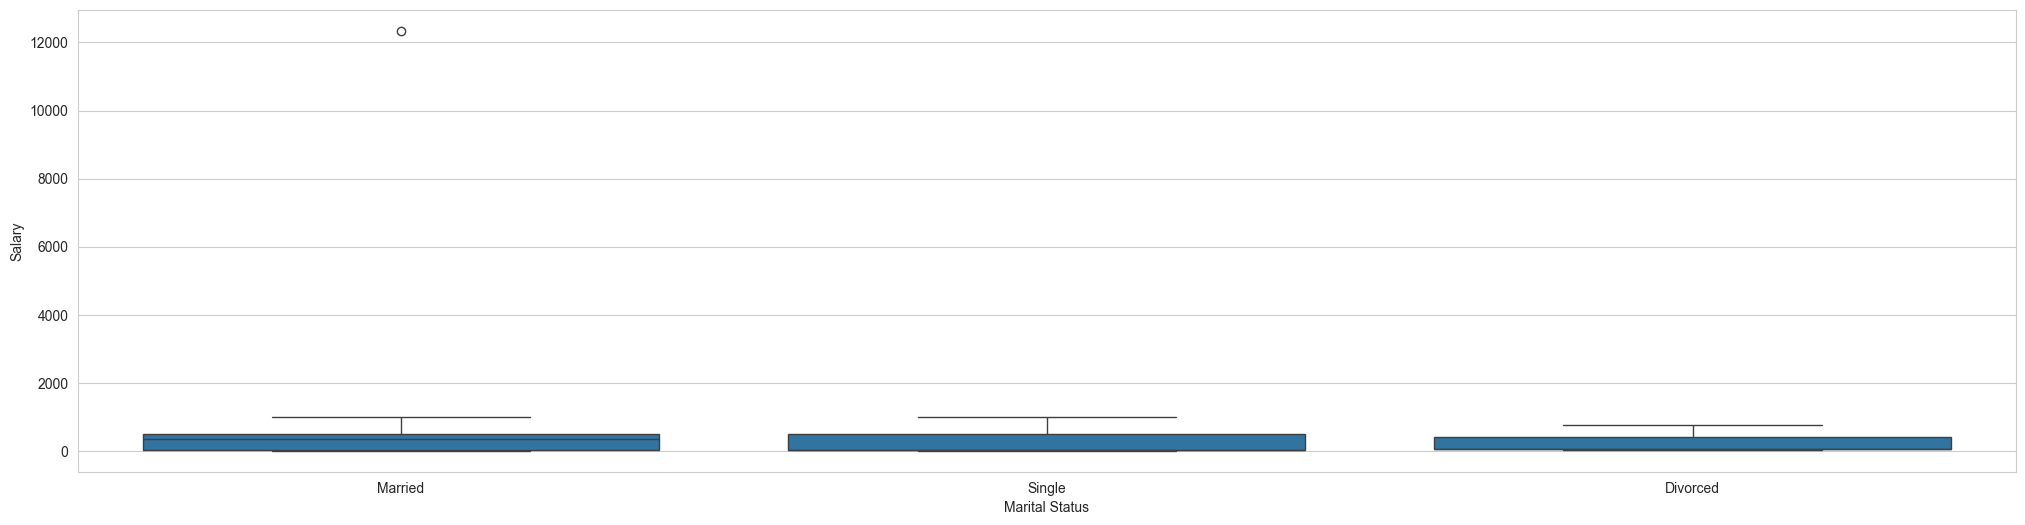

In [11]:
sns.set_style('whitegrid')

plt.figure(figsize = (25, 6))
sns.boxplot(data = df, x = 'Marital Status', y = 'Salary')

plt.show()

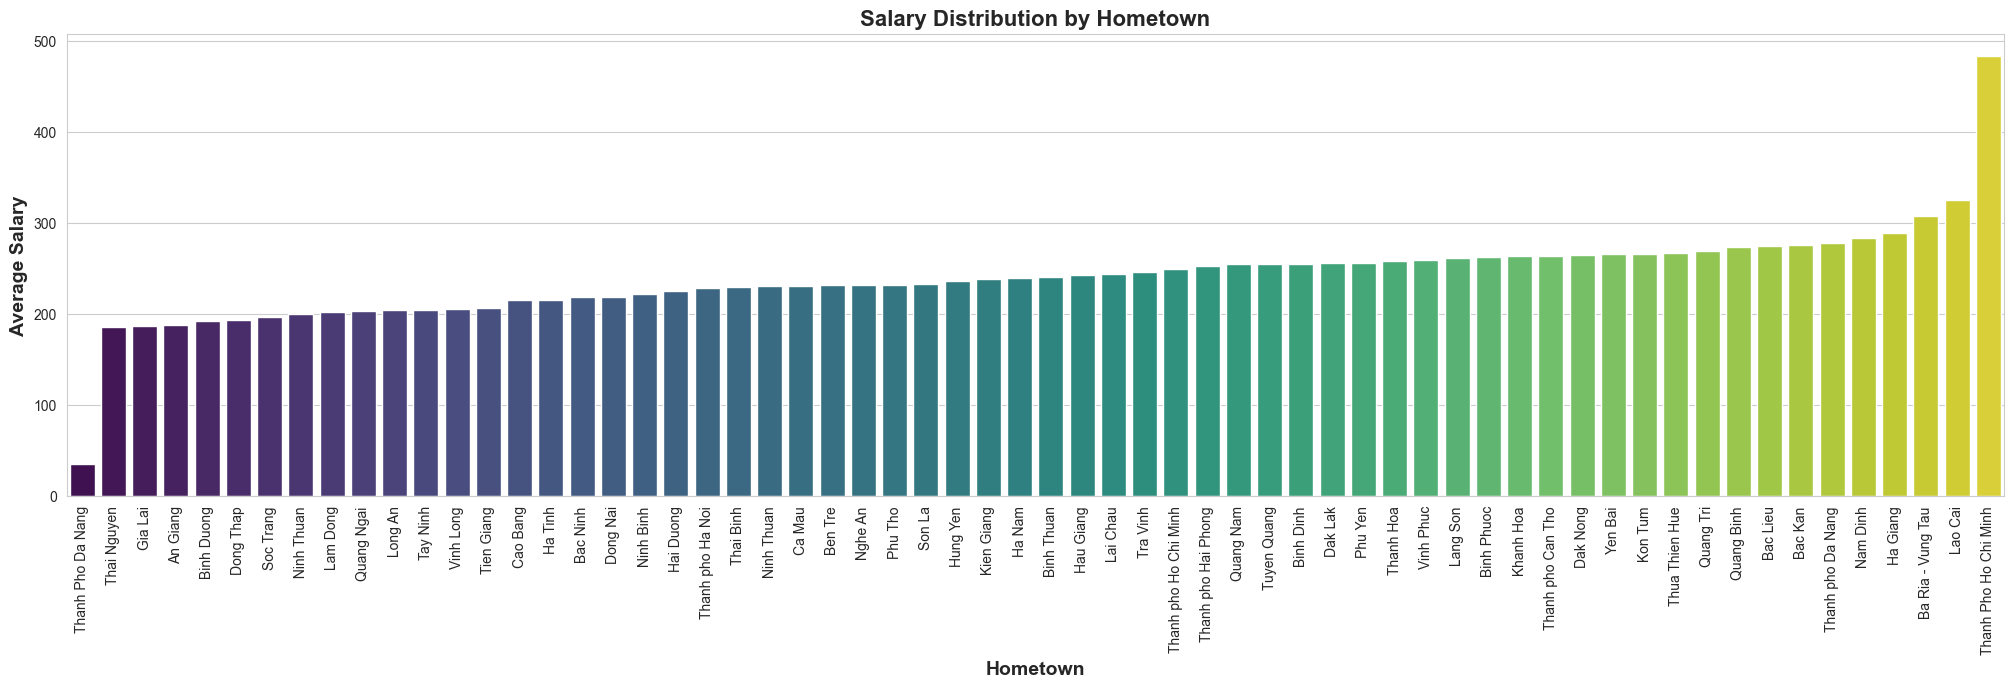

In [12]:
salary_hometown =  df.groupby('Hometown')['Salary'].mean().reset_index().sort_values(by = 'Salary', ascending = True)

plt.figure(figsize = (25, 6))

sns.barplot(x = 'Hometown', y = 'Salary', data = salary_hometown, palette= 'viridis', ci = None)

plt.xticks(rotation = 90)

plt.title('Salary Distribution by Hometown', fontsize = 16, fontweight = 'bold')
plt.xlabel('Hometown', fontsize=14, fontweight = 'bold')
plt.ylabel('Average Salary', fontsize=14, fontweight = 'bold')

plt.show()

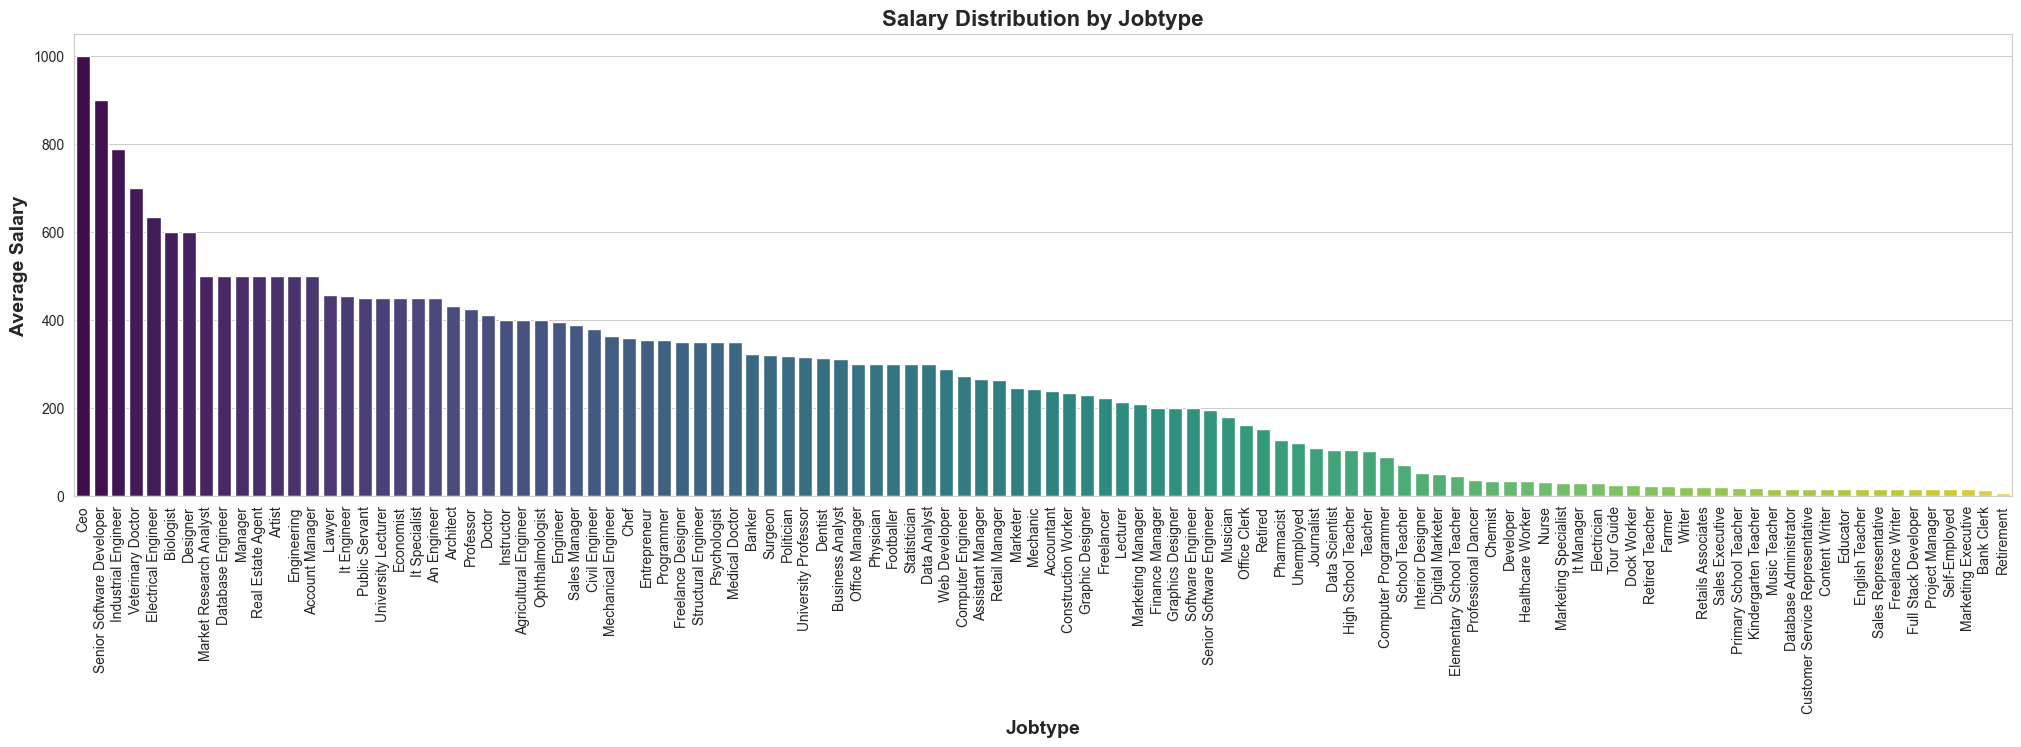

In [13]:
salary_Jobtype =  df.groupby('Jobtype')['Salary'].mean().reset_index().sort_values(by = 'Salary', ascending = False)

plt.figure(figsize = (25, 6))

sns.barplot(x = 'Jobtype', y = 'Salary', data = salary_Jobtype, palette= 'viridis', ci = None)

plt.xticks(rotation = 90)

plt.title('Salary Distribution by Jobtype', fontsize = 16, fontweight = 'bold')
plt.xlabel('Jobtype', fontsize=14, fontweight = 'bold')
plt.ylabel('Average Salary', fontsize=14, fontweight = 'bold')

plt.show()